In [ ]:
# import kagglehub

# # Download latest version
# path = kagglehub.dataset_download("brunogrisci/breast-cancer-gene-expression-cumida")

# print("Path to dataset files:", path)

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, accuracy_score

# TDA imports
from ripser import ripser
from persim import PersLandscapeApprox
# from persim import plot_landscape
import subprocess
import tempfile
import os
import sys

sys.path.append(os.path.abspath('../..'))
from tda import plot_barcodes, plot_landscapes, takens_embedding

In [ ]:
# PRZYKŁAD: Wczytanie danych z pliku CSV
# df = pd.read_csv('Breast_GSE45827.csv') # Przykładowy plik z CuMiDa
# X = df.drop(['samples', 'type'], axis=1).values
# y = df['type'].values

# Na potrzeby demonstracji generujemy syntetyczne dane symulujące 3 podtypy raka piersi
np.random.seed(42)
n_samples = 150
n_genes = 5000

# Symulacja: 3 klasy (np. Basal, HER2, Luminal)
X_sim = np.vstack([
    np.random.normal(loc=0.0, scale=1.0, size=(50, n_genes)),
    np.random.normal(loc=0.5, scale=1.2, size=(50, n_genes)),
    np.random.normal(loc=-0.5, scale=0.8, size=(50, n_genes))
])
y_sim = np.array(['Basal']*50 + ['HER2']*50 + ['Luminal']*50)

# 1. Standaryzacja
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_sim)

# 2. Redukcja wymiarów (PCA)
pca = PCA(n_components=50)
X_pca = pca.fit_transform(X_scaled)

print(f"Kształt danych po PCA: {X_pca.shape}")

In [ ]:
# Opcja 1: Standardowy Ripser z scikit-tda (zalecane)
def compute_diagrams_python(X, maxdim=1):
    res = ripser(X, maxdim=maxdim)
    return res['dgms']

# Opcja 2: Wywołanie zewnętrznego pliku binarnego Ripser (C++)
def run_custom_ripser_cpp(X, ripser_path='/sciezka/do/ripser', maxdim=1):
    with tempfile.NamedTemporaryFile(mode='w', delete=False, suffix='.csv') as f:
        np.savetxt(f, X, delimiter=',')
        temp_path = f.name
        
    diagrams = []
    try:
        result = subprocess.run(
            [ripser_path, '--dim', str(maxdim), '--format', 'point-cloud', temp_path],
            capture_output=True, text=True, check=True
        )
        print("Wywołano pomyślnie binarnego Ripsera. Surowe wyjście:")
        print(result.stdout[:200] + "...\n(Wymaga parsowania do formatu numpy array)")
    except Exception as e:
        print(f"Błąd podczas wywoływania Ripser C++: {e}")
    finally:
        os.remove(temp_path)
        
    return diagrams

diagrams = compute_diagrams_python(X_pca, maxdim=1)

In [ ]:
# Ekstrakcja tylko diagramów wymiaru 1 (pętle, H1)
H1_diagram = diagrams[1]

# Czyste H1 (usunięcie punktów z nieskończonym czasem śmierci)
H1_diagram = H1_diagram[H1_diagram[:, 1] != np.inf]

# Parametry krajobrazu
num_steps = 100
num_landscapes = 5

pla = PersLandscapeApprox(num_steps=num_steps, num_landscapes=num_landscapes)

if len(H1_diagram) > 0:
    landscape = pla.transform([H1_diagram])[0]
    
    plt.figure(figsize=(10, 5))
    plot_landscapes(landscape)
    plt.title("Krajobraz Persystentny (Wymiar 1)")
    plt.show()
    
    features = landscape.flatten()
    print(f"Kształt wektora cech topologicznych: {features.shape}")
else:
    print("Brak cech H1 do narysowania krajobrazu.")

In [ ]:
# Symulacja macierzy cech wyekstrahowanych z krajobrazów persystentnych dla 150 pacjentów
X_tda_simulated = np.random.rand(n_samples, 500) # 5 krajobrazów x 100 kroków

X_train, X_test, y_train, y_test = train_test_split(X_tda_simulated, y_sim, test_size=0.3, random_state=42)

clf = RandomForestClassifier(n_estimators=100, random_state=42)
clf.fit(X_train, y_train)

y_pred = clf.predict(X_test)

print("Raport Klasyfikacji (Na wektorach z krajobrazów):\n")
print(classification_report(y_test, y_pred))
print(f"Dokładność (Accuracy): {accuracy_score(y_test, y_pred):.2f}")

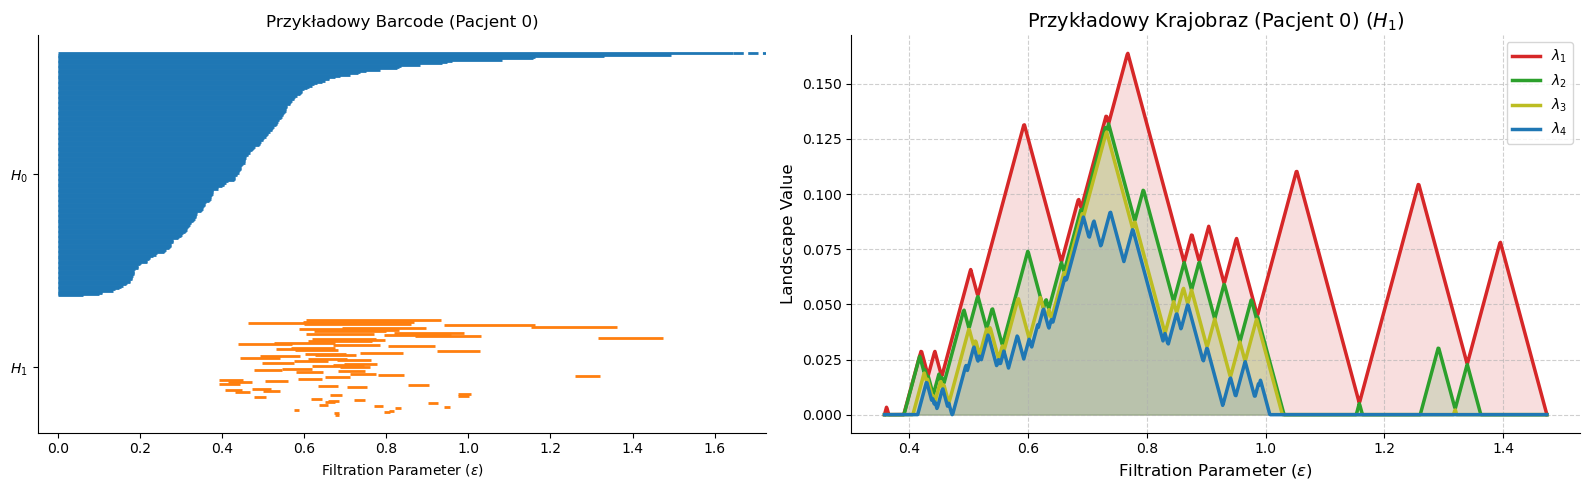

Raport Klasyfikacji (na cechach z krajobrazów):
              precision    recall  f1-score   support

       Basal       0.56      0.47      0.51        19
        HER2       0.57      0.62      0.59        13
     Luminal       0.73      0.85      0.79        13

    accuracy                           0.62        45
   macro avg       0.62      0.65      0.63        45
weighted avg       0.61      0.62      0.62        45

Accuracy: 0.62


In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, accuracy_score
from ripser import ripser

# ==========================================
# WŁASNE FUNKCJE
# ==========================================

def plot_barcodes(dgms, ax, title, min_persistence=0.01):
    """Custom barcode plotting function with topological noise filtering."""
    colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728', '#9467bd', '#8c564b']
    
    max_death = 0
    for dgm in dgms:
        if len(dgm) > 0:
            finite_deaths = dgm[dgm[:, 1] != np.inf][:, 1]
            if len(finite_deaths) > 0:
                max_death = max(max_death, np.max(finite_deaths))
                
    inf_end = max_death * 1.1 if max_death > 0 else 1.0
    current_y = 0
    yticks, ytick_labels = [], []
    
    for dim, dgm in enumerate(dgms):
        if len(dgm) == 0: continue
            
        persistence = np.where(np.isinf(dgm[:, 1]), inf_end * 2, dgm[:, 1]) - dgm[:, 0]
        valid_indices = np.where(persistence >= min_persistence)[0] if dim > 0 else np.arange(len(dgm))
        dgm_filtered = dgm[valid_indices]
        persistence_filtered = persistence[valid_indices]
        
        if len(dgm_filtered) == 0: continue
        
        sorted_indices = np.argsort(persistence_filtered)[::-1]
        sorted_dgm = dgm_filtered[sorted_indices]
        
        start_y = current_y
        for birth, death in sorted_dgm:
            is_inf = np.isinf(death)
            plot_death = inf_end if is_inf else death
            
            ax.hlines(y=current_y, xmin=birth, xmax=plot_death, colors=colors[dim % len(colors)], linewidth=2)
            if is_inf:
                ax.hlines(y=current_y, xmin=plot_death, xmax=inf_end * 1.05, colors=colors[dim % len(colors)], linewidth=2, linestyles='dashed')
            current_y += 1
            
        mid_y = (start_y + current_y - 1) / 2.0
        yticks.append(mid_y)
        ytick_labels.append(f"$H_{dim}$")
        current_y += max(3, int(len(dgm_filtered) * 0.1))
        
    ax.set_yticks(yticks)
    ax.set_yticklabels(ytick_labels)
    ax.set_xlabel("Filtration Parameter ($\epsilon$)")
    ax.set_title(title)
    ax.set_xlim(left=-0.05, right=inf_end * 1.05)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.invert_yaxis()

def plot_landscapes(dgms, ax, title, target_dim=1, max_k=4):
    """Custom persistence landscape plotting function using lambda_k(t)."""
    colors = ['#d62728', '#2ca02c', '#bcbd22', '#1f77b4', '#ff7f0e']
    
    if target_dim >= len(dgms) or len(dgms[target_dim]) == 0:
        ax.set_title(f"{title} - Brak cech w H_{target_dim}")
        return
        
    dgm = dgms[target_dim]
    finite_dgm = dgm[dgm[:, 1] != np.inf]
    
    if len(finite_dgm) == 0:
        ax.set_title(f"{title} - Brak skończonych cech w H_{target_dim}")
        return

    min_birth, max_death = np.min(finite_dgm[:, 0]), np.max(finite_dgm[:, 1])
    t_vals = np.linspace(min_birth, max_death, 1000)
    
    b, d, t = finite_dgm[:, 0][:, None], finite_dgm[:, 1][:, None], t_vals[None, :]
    tents = np.maximum(0, np.minimum(t - b, d - t))
    tents_sorted = np.sort(tents, axis=0)[::-1, :]
    
    actual_k = min(max_k, len(finite_dgm))
    for k in range(actual_k):
        ax.plot(t_vals, tents_sorted[k, :], label=f'$\lambda_{{{k+1}}}$', color=colors[k % len(colors)], linewidth=2.5)
        ax.fill_between(t_vals, tents_sorted[k, :], alpha=0.15, color=colors[k % len(colors)])
        
    ax.set_title(f"{title} ($H_{target_dim}$)", fontsize=14)
    ax.set_xlabel("Filtration Parameter ($\epsilon$)", fontsize=12)
    ax.set_ylabel("Landscape Value", fontsize=12)
    ax.legend(loc='upper right')
    ax.grid(True, linestyle='--', alpha=0.6)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

def takens_embedding(series, delay, dimension):
    """
    Creates a Takens embedding (time-delay embedding) for a 1D time series.
    series: 1D numpy array of the time series data
    delay: the time delay (tau) -
    """
    N = len(series)
    if N - (dimension - 1) * delay <= 0:
        raise ValueError("Time series is too short for this dimension/delay.")

    embedded = np.array([series[i : i + (dimension - 1) * delay + 1 : delay]
                         for i in range(N - (dimension - 1) * delay)])
    return embedded

# Funkcja wektoryzująca na bazie Twojej logiki krajobrazów do ML
def extract_landscape_features(dgm, max_k=4, resolution=100):
    finite_dgm = dgm[dgm[:, 1] != np.inf]
    if len(finite_dgm) == 0:
        return np.zeros(max_k * resolution)
    
    min_birth, max_death = np.min(finite_dgm[:, 0]), np.max(finite_dgm[:, 1])
    if min_birth == max_death:
        return np.zeros(max_k * resolution)
        
    t_vals = np.linspace(min_birth, max_death, resolution)
    b, d, t = finite_dgm[:, 0][:, None], finite_dgm[:, 1][:, None], t_vals[None, :]
    tents = np.maximum(0, np.minimum(t - b, d - t))
    tents_sorted = np.sort(tents, axis=0)[::-1, :]
    
    actual_k = min(max_k, len(finite_dgm))
    features = np.zeros((max_k, resolution))
    features[:actual_k, :] = tents_sorted[:actual_k, :]
    return features.flatten()

# ==========================================
# SYMULACJA I TDA W UŻYCIU
# ==========================================

np.random.seed(42)
n_samples = 150
n_genes = 200 # Przykładowa długość ekspresji genów dla pacjenta

# Symulacja trzech typów
X_sim = np.vstack([
    np.random.normal(loc=0.0, scale=1.0, size=(50, n_genes)),
    np.random.normal(loc=0.5, scale=1.2, size=(50, n_genes)),
    np.random.normal(loc=-0.5, scale=0.8, size=(50, n_genes))
])
y_sim = np.array(['Basal']*50 + ['HER2']*50 + ['Luminal']*50)

X_tda_features = []
all_dgms = []

for i in range(n_samples):
    # Sekwencja reprezentująca dany wiersz
    patient_sequence = X_sim[i]
    
    # Zamiana w chmurę punktów
    pc = takens_embedding(patient_sequence, delay=2, dimension=3)
    
    # Obliczenia TDA
    res = ripser(pc, maxdim=1)
    dgms = res['dgms']
    all_dgms.append(dgms)
    
    # Wektoryzacja wymiaru H1 
    feats = extract_landscape_features(dgms[1] if len(dgms)>1 else np.array([]), max_k=4, resolution=100)
    X_tda_features.append(feats)

X_tda_features = np.array(X_tda_features)

# ==========================================
# RYSOWANIE
# ==========================================

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 5))
sample_dgms = all_dgms[0]
plot_barcodes(sample_dgms, ax1, title="Przykładowy Barcode (Pacjent 0)")
plot_landscapes(sample_dgms, ax2, title="Przykładowy Krajobraz (Pacjent 0)", target_dim=1, max_k=4)
plt.tight_layout()
plt.show()

# ==========================================
# KLASYFIKACJA ML
# ==========================================

X_train, X_test, y_train, y_test = train_test_split(X_tda_features, y_sim, test_size=0.3, random_state=42)

clf = RandomForestClassifier(n_estimators=100, random_state=42)
clf.fit(X_train, y_train)
y_pred = clf.predict(X_test)

print("Raport Klasyfikacji (na cechach z krajobrazów):")
print(classification_report(y_test, y_pred))
print(f"Accuracy: {accuracy_score(y_test, y_pred):.2f}")

Wczytywanie danych z pliku Breast_GSE45827.csv...
Liczba próbek: 151
Oryginalna liczba genów: 54675

Wykonuję redukcję PCA by uniknąć MemoryError (do max 100 cech).
Dane zredukowano do kształtu: (151, 100)

Obliczanie cech TDA (Takens -> Ripser -> Landscapes)...
Przetworzono 10/151 próbek...
Przetworzono 20/151 próbek...
Przetworzono 30/151 próbek...
Przetworzono 40/151 próbek...
Przetworzono 50/151 próbek...
Przetworzono 60/151 próbek...
Przetworzono 70/151 próbek...
Przetworzono 80/151 próbek...
Przetworzono 90/151 próbek...
Przetworzono 100/151 próbek...
Przetworzono 110/151 próbek...
Przetworzono 120/151 próbek...
Przetworzono 130/151 próbek...
Przetworzono 140/151 próbek...
Przetworzono 150/151 próbek...


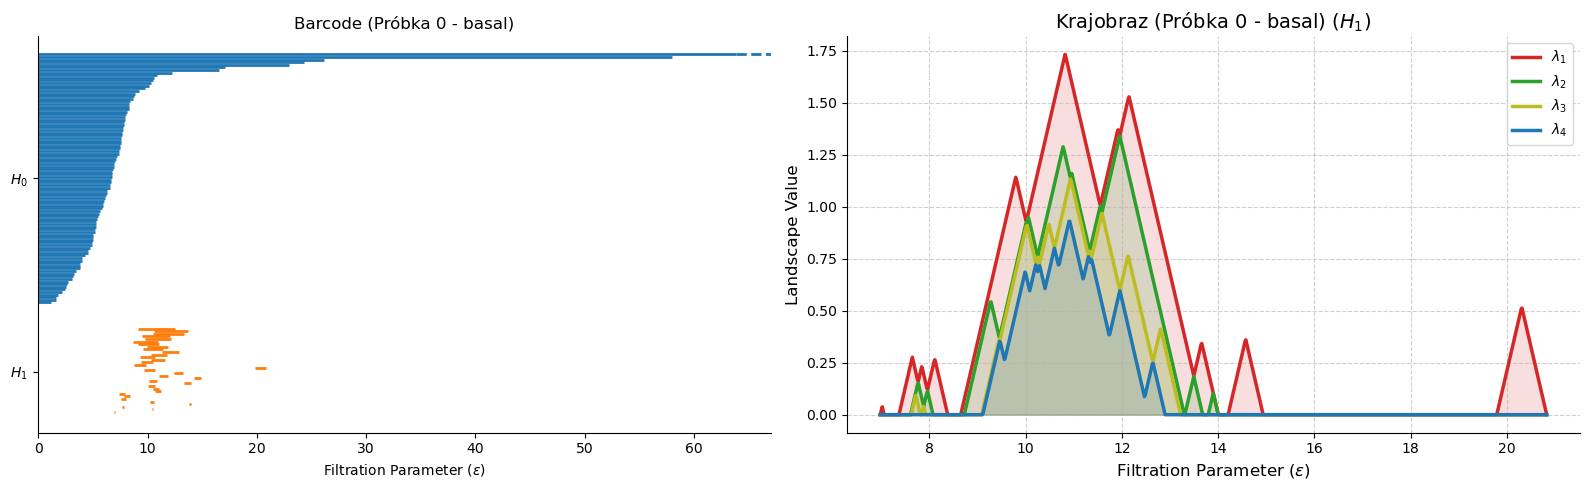


Klasyfikacja ML na wyciągniętych wektorach krajobrazów...

--- Raport Klasyfikacji ---
              precision    recall  f1-score   support

         HER       0.22      0.25      0.24         8
       basal       0.38      0.29      0.33        17
   cell_line       0.50      0.20      0.29         5
   luminal_A       0.21      0.75      0.33         4
   luminal_B       0.14      0.09      0.11        11
      normal       0.00      0.00      0.00         1

    accuracy                           0.26        46
   macro avg       0.24      0.26      0.22        46
weighted avg       0.29      0.26      0.25        46

Dokładność (Accuracy): 0.26


In [5]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, accuracy_score
from ripser import ripser

# ==========================================
# WŁASNE FUNKCJE UŻYTKOWNIKA
# ==========================================

def plot_barcodes(dgms, ax, title, min_persistence=0.01):
    colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728', '#9467bd', '#8c564b']
    max_death = 0
    for dgm in dgms:
        if len(dgm) > 0:
            finite_deaths = dgm[dgm[:, 1] != np.inf][:, 1]
            if len(finite_deaths) > 0:
                max_death = max(max_death, np.max(finite_deaths))
                
    inf_end = max_death * 1.1 if max_death > 0 else 1.0
    current_y = 0
    yticks, ytick_labels = [], []
    
    for dim, dgm in enumerate(dgms):
        if len(dgm) == 0: continue
            
        persistence = np.where(np.isinf(dgm[:, 1]), inf_end * 2, dgm[:, 1]) - dgm[:, 0]
        valid_indices = np.where(persistence >= min_persistence)[0] if dim > 0 else np.arange(len(dgm))
        dgm_filtered = dgm[valid_indices]
        persistence_filtered = persistence[valid_indices]
        
        if len(dgm_filtered) == 0: continue
        
        sorted_indices = np.argsort(persistence_filtered)[::-1]
        sorted_dgm = dgm_filtered[sorted_indices]
        
        start_y = current_y
        for birth, death in sorted_dgm:
            is_inf = np.isinf(death)
            plot_death = inf_end if is_inf else death
            
            ax.hlines(y=current_y, xmin=birth, xmax=plot_death, colors=colors[dim % len(colors)], linewidth=2)
            if is_inf:
                ax.hlines(y=current_y, xmin=plot_death, xmax=inf_end * 1.05, colors=colors[dim % len(colors)], linewidth=2, linestyles='dashed')
            current_y += 1
            
        mid_y = (start_y + current_y - 1) / 2.0
        yticks.append(mid_y)
        ytick_labels.append(f"$H_{dim}$")
        current_y += max(3, int(len(dgm_filtered) * 0.1))
        
    ax.set_yticks(yticks)
    ax.set_yticklabels(ytick_labels)
    ax.set_xlabel("Filtration Parameter ($\epsilon$)")
    ax.set_title(title)
    ax.set_xlim(left=-0.05, right=inf_end * 1.05)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.invert_yaxis()

def plot_landscapes(dgms, ax, title, target_dim=1, max_k=4):
    colors = ['#d62728', '#2ca02c', '#bcbd22', '#1f77b4', '#ff7f0e']
    if target_dim >= len(dgms) or len(dgms[target_dim]) == 0:
        ax.set_title(f"{title} - Brak cech w H_{target_dim}")
        return
        
    dgm = dgms[target_dim]
    finite_dgm = dgm[dgm[:, 1] != np.inf]
    
    if len(finite_dgm) == 0:
        ax.set_title(f"{title} - Brak skończonych cech w H_{target_dim}")
        return

    min_birth, max_death = np.min(finite_dgm[:, 0]), np.max(finite_dgm[:, 1])
    t_vals = np.linspace(min_birth, max_death, 1000)
    
    b, d, t = finite_dgm[:, 0][:, None], finite_dgm[:, 1][:, None], t_vals[None, :]
    tents = np.maximum(0, np.minimum(t - b, d - t))
    tents_sorted = np.sort(tents, axis=0)[::-1, :]
    
    actual_k = min(max_k, len(finite_dgm))
    for k in range(actual_k):
        ax.plot(t_vals, tents_sorted[k, :], label=f'$\lambda_{{{k+1}}}$', color=colors[k % len(colors)], linewidth=2.5)
        ax.fill_between(t_vals, tents_sorted[k, :], alpha=0.15, color=colors[k % len(colors)])
        
    ax.set_title(f"{title} ($H_{target_dim}$)", fontsize=14)
    ax.set_xlabel("Filtration Parameter ($\epsilon$)", fontsize=12)
    ax.set_ylabel("Landscape Value", fontsize=12)
    ax.legend(loc='upper right')
    ax.grid(True, linestyle='--', alpha=0.6)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

def takens_embedding(series, delay, dimension):
    N = len(series)
    if N - (dimension - 1) * delay <= 0:
        raise ValueError("Time series is too short for this dimension/delay.")
    embedded = np.array([series[i : i + (dimension - 1) * delay + 1 : delay]
                         for i in range(N - (dimension - 1) * delay)])
    return embedded

def extract_landscape_features(dgm, max_k=4, resolution=100):
    finite_dgm = dgm[dgm[:, 1] != np.inf]
    if len(finite_dgm) == 0:
        return np.zeros(max_k * resolution)
        
    min_birth, max_death = np.min(finite_dgm[:, 0]), np.max(finite_dgm[:, 1])
    if min_birth == max_death:
        return np.zeros(max_k * resolution)
        
    t_vals = np.linspace(min_birth, max_death, resolution)
    b, d, t = finite_dgm[:, 0][:, None], finite_dgm[:, 1][:, None], t_vals[None, :]
    tents = np.maximum(0, np.minimum(t - b, d - t))
    tents_sorted = np.sort(tents, axis=0)[::-1, :]
    
    actual_k = min(max_k, len(finite_dgm))
    features = np.zeros((max_k, resolution))
    features[:actual_k, :] = tents_sorted[:actual_k, :]
    
    return features.flatten()

# ==========================================
# GŁÓWNY KOD (WCZYTANIE, TDA, ML)
# ==========================================

if __name__ == "__main__":
    print("Wczytywanie danych z pliku Breast_GSE45827.csv...")
    try:
        df = pd.read_csv('Breast_GSE45827.csv')
        
        if 'type' in df.columns:
            y = df['type'].values
        else:
            y = df.iloc[:, -1].values
            
        # Zignorowanie niepotrzebnych kolumn
        X_raw = df.drop(['samples', 'type'], axis=1, errors='ignore').values
        
        n_samples, n_genes_raw = X_raw.shape
        print(f"Liczba próbek: {n_samples}")
        print(f"Oryginalna liczba genów: {n_genes_raw}")
        
        # --- KLUCZOWA POPRAWKA OMIJAJĄCA MEMORY ERROR ---
        # PCA zredukuje 54000 wymiarów np. do 1000 głównych składowych na całą populację,
        # LUB - ponieważ chcemy takens na pacjenta - użyjemy PCA globalnie.
        # Należy pamiętać, że n_components w PCA nie może być większe od min(n_samples, n_features).
        # Mając np. 150 pacjentów, PCA zredukuje to maksymalnie do 150-1 wymiarów.
        
        max_components = min(100, n_samples) 
        print(f"\nWykonuję redukcję PCA by uniknąć MemoryError (do max {max_components} cech).")
        pca = PCA(n_components=max_components)
        X_reduced = pca.fit_transform(X_raw)
        
        print(f"Dane zredukowano do kształtu: {X_reduced.shape}")
        
        # Opcja B (alternatywna, gdyby PCA traciło ważny sygnał TDA dla jednego pacjenta):
        # Wybór N genów o najwyższej wariancji (odkomentuj jeśli wolisz zamiast PCA)
        # variances = np.var(X_raw, axis=0)
        # top_indices = np.argsort(variances)[-1000:] 
        # X_reduced = X_raw[:, top_indices]
        # print(f"Wybrano top geny. Nowy kształt to: {X_reduced.shape}")

        print("\nObliczanie cech TDA (Takens -> Ripser -> Landscapes)...")
        
        X_tda_features = []
        all_dgms = []
        
        for i in range(n_samples):
            # Traktujemy *zredukowaną* ekspresję danego pacjenta jako sekwencję 1D
            patient_sequence = X_reduced[i]
            
            # 1. Zanurzenie Takensa
            # Uwaga: dla krótkiego sygnału (np. 150) nie twórz chmury o ogromnych opóźnieniach.
            pc = takens_embedding(patient_sequence, delay=2, dimension=3)
            
            # 2. Ripser (Homologie persystentne)
            res = ripser(pc, maxdim=1)
            dgms = res['dgms']
            all_dgms.append(dgms)
            
            # 3. Wektoryzacja wymiaru H1
            feats = extract_landscape_features(dgms[1] if len(dgms)>1 else np.array([]), max_k=4, resolution=100)
            X_tda_features.append(feats)
            
            if (i + 1) % 10 == 0:
                print(f"Przetworzono {i+1}/{n_samples} próbek...")
                
        X_tda_features = np.array(X_tda_features)
        
        # Wyświetlenie przykładowych wykresów dla pacjenta nr 0
        fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 5))
        plot_barcodes(all_dgms[0], ax1, title=f"Barcode (Próbka 0 - {y[0]})")
        plot_landscapes(all_dgms[0], ax2, title=f"Krajobraz (Próbka 0 - {y[0]})", target_dim=1, max_k=4)
        plt.tight_layout()
        plt.show()
        
        # 4. Klasyfikacja ML
        print("\nKlasyfikacja ML na wyciągniętych wektorach krajobrazów...")
        X_train, X_test, y_train, y_test = train_test_split(X_tda_features, y, test_size=0.3, random_state=42)
        
        clf = RandomForestClassifier(n_estimators=100, random_state=42)
        clf.fit(X_train, y_train)
        y_pred = clf.predict(X_test)
        
        print("\n--- Raport Klasyfikacji ---")
        print(classification_report(y_test, y_pred))
        print(f"Dokładność (Accuracy): {accuracy_score(y_test, y_pred):.2f}")

    except FileNotFoundError:
        print("BŁĄD: Nie znaleziono pliku 'Breast_GSE45827.csv'. Upewnij się, że jest w tym samym folderze co skrypt.")

1. Wczytywanie i redukcja danych...
2. Obliczanie diagramów persystencji (Ripser)...
3. Poszukiwanie globalnego maksimum dla osi filtracji...
   -> Globalne maksimum ustalone na: 89.941
4. Obliczanie krajobrazów na wspólnej siatce...
5. Uśrednianie krajobrazów...


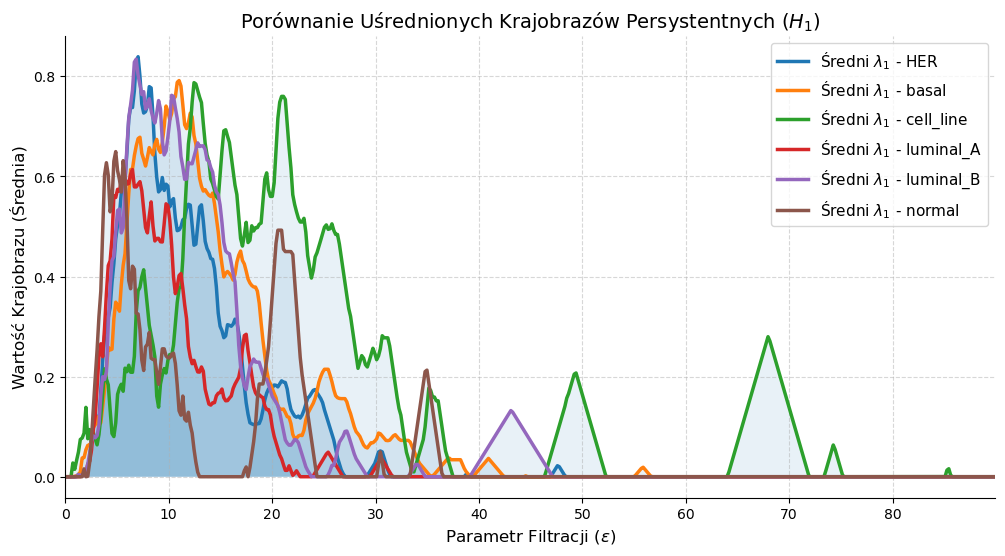

In [8]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from ripser import ripser

# =====================================================================
# FUNKCJE UŻYTKOWNIKA
# =====================================================================
def takens_embedding(series, delay=2, dimension=3):
    N = len(series)
    return np.array([series[i : i + (dimension - 1) * delay + 1 : delay]
                     for i in range(N - (dimension - 1) * delay)])

def compute_landscape_on_grid(dgm, t_vals, max_k=4):
    landscape_grid = np.zeros((max_k, len(t_vals)))
    finite_dgm = dgm[dgm[:, 1] != np.inf]
    if len(finite_dgm) == 0:
        return landscape_grid
        
    b, d, t = finite_dgm[:, 0][:, None], finite_dgm[:, 1][:, None], t_vals[None, :]
    tents = np.maximum(0, np.minimum(t - b, d - t))
    tents_sorted = np.sort(tents, axis=0)[::-1, :]
    
    actual_k = min(max_k, len(finite_dgm))
    landscape_grid[:actual_k, :] = tents_sorted[:actual_k, :]
    return landscape_grid

# =====================================================================
# GŁÓWNY PROCES PRZETWARZANIA
# =====================================================================
if __name__ == "__main__":
    print("1. Wczytywanie i redukcja danych...")
    df = pd.read_csv('Breast_GSE45827.csv')
    y = df['type'].values if 'type' in df.columns else df.iloc[:, -1].values
    X_raw = df.drop(['samples', 'type'], axis=1, errors='ignore').values
    
    pca = PCA(n_components=min(400, len(X_raw)))
    X_reduced = pca.fit_transform(X_raw)
    
    all_dgms_h1 = []
    patient_types = []
    subtypes = np.unique(y)
    
    print("2. Obliczanie diagramów persystencji (Ripser)...")
    for i in range(len(X_reduced)):
        pc = takens_embedding(X_reduced[i], delay=2, dimension=3)
        res = ripser(pc, maxdim=1)
        dgm_h1 = res['dgms'][1] if len(res['dgms']) > 1 else np.array([])
        
        all_dgms_h1.append(dgm_h1)
        patient_types.append(y[i])

    # --- ZNAJDOWANIE GLOBALNEGO MAKSIMUM ---
    print("3. Poszukiwanie globalnego maksimum dla osi filtracji...")
    global_max_death = 0.0
    for dgm in all_dgms_h1:
        finite_dgm = dgm[dgm[:, 1] != np.inf]
        if len(finite_dgm) > 0:
            local_max = np.max(finite_dgm[:, 1])
            if local_max > global_max_death:
                global_max_death = local_max
                
    # Dodajemy 5% marginesu z prawej strony, żeby wykres ładnie schodził do zera
    global_max_death *= 1.05 
    if global_max_death == 0: 
        global_max_death = 1.0 # Zabezpieczenie na wypadek pustych diagramów
        
    print(f"   -> Globalne maksimum ustalone na: {global_max_death:.3f}")
    
    # Tworzymy idealnie dopasowaną oś!
    global_t_vals = np.linspace(0.0, global_max_death, 500)
    max_k = 4
    
    print("4. Obliczanie krajobrazów na wspólnej siatce...")
    subtype_landscapes_list = {sub: [] for sub in subtypes}
    
    for i in range(len(all_dgms_h1)):
        dgm_h1 = all_dgms_h1[i]
        p_type = patient_types[i]
        
        land = compute_landscape_on_grid(dgm_h1, global_t_vals, max_k=max_k)
        subtype_landscapes_list[p_type].append(land)
        
    print("5. Uśrednianie krajobrazów...")
    averaged_landscapes = {}
    for sub in subtypes:
        arr = np.array(subtype_landscapes_list[sub])
        averaged_landscapes[sub] = np.mean(arr, axis=0)
    
    # =====================================================================
    # WIZUALIZACJA
    # =====================================================================
    plt.figure(figsize=(12, 6))
    
    target_k_idx = 0 # Wybieramy pierwszy krajobraz (lambda_1)
    colors = {'Basal': '#d62728', 'HER2': '#ff7f0e', 'Luminal': '#1f77b4', 'Normal': '#2ca02c'}
    
    for sub in subtypes:
        lambda_1_averaged = averaged_landscapes[sub][target_k_idx, :]
        color = colors.get(sub, None)
        
        plt.plot(global_t_vals, lambda_1_averaged, label=f'Średni $\lambda_1$ - {sub}', linewidth=2.5, color=color)
        plt.fill_between(global_t_vals, lambda_1_averaged, alpha=0.1, color=color)
        
    plt.title("Porównanie Uśrednionych Krajobrazów Persystentnych ($H_1$)", fontsize=14)
    plt.xlabel("Parametr Filtracji ($\epsilon$)", fontsize=12)
    plt.ylabel("Wartość Krajobrazu (Średnia)", fontsize=12)
    plt.legend(fontsize=11)
    plt.grid(True, linestyle='--', alpha=0.5)
    plt.gca().spines['top'].set_visible(False)
    plt.gca().spines['right'].set_visible(False)
    plt.xlim(left=0.0, right=global_max_death)
    plt.show()